In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
band = "beta"

df_mu_10 = pd.read_csv(f'resultados_rqa_{band}/carga_10_{band}.csv')
df_mu_5 = pd.read_csv(f'resultados_rqa_{band}/carga_5_{band}.csv')
df_mu_0 = pd.read_csv(f'resultados_rqa_{band}/carga_0_{band}.csv')
df_mu_0.drop(df_mu_0[df_mu_0["determinism"] == 0].index, inplace=True)
df_mu_5.drop(df_mu_5[df_mu_5["determinism"] == 0].index, inplace=True)
df_mu_10.drop(df_mu_10[df_mu_10["determinism"] == 0].index, inplace=True)

df_mu_0.reset_index(drop=True, inplace=True)
df_mu_5.reset_index(drop=True, inplace=True)
df_mu_10.reset_index(drop=True, inplace=True)


In [24]:
#df_mu_0.drop(index=range(28010, 29234), inplace=False)


In [25]:
df_mu_0

,recurrence_rate,determinism,trapping_time,diag_entropy,vert_entropy,laminarity,Binaria,banda,archivo,condicion,sujeto,sesion
0,0.260000,0.849315,4.153488,1.450211,1.932627,0.954060,0.0,beta,pasivoPre.csv,0% Torque,AlejandoPayan,S1
1,0.358889,0.949675,6.520619,1.986399,2.377601,0.979102,0.0,beta,pasivoPre.csv,0% Torque,AlejandoPayan,S1
2,0.449444,0.957638,6.870690,1.997591,2.538217,0.985167,0.0,beta,pasivoPre.csv,0% Torque,AlejandoPayan,S1
3,0.486667,0.957447,6.200717,1.867356,2.452292,0.987443,1.0,beta,pasivoPre.csv,0% Torque,AlejandoPayan,S1
4,0.492778,0.906651,5.286154,1.823057,2.212693,0.968433,1.0,beta,pasivoPre.csv,0% Torque,AlejandoPayan,S1
...,...,...,...,...,...,...,...,...,...,...,...,...
4766,0.306667,0.833333,4.504348,1.644226,2.026860,0.938406,1.0,beta,pasivoPre.csv,0% Torque,TemanyaReyes,S3
4767,0.208333,0.797101,4.000000,1.416154,1.827462,0.922667,0.0,beta,pasivoPre.csv,0% Torque,TemanyaReyes,S3
4768,0.215000,0.770308,4.188235,1.745960,1.780381,0.919897,0.0,beta,pasivoPre.csv,0% Torque,TemanyaReyes,S3
4769,0.396111,0.882870,6.048889,2.045263,2.261961,0.954418,0.0,beta,pasivoPre.csv,0% Torque,TemanyaReyes,S3


In [26]:
%matplotlib inline

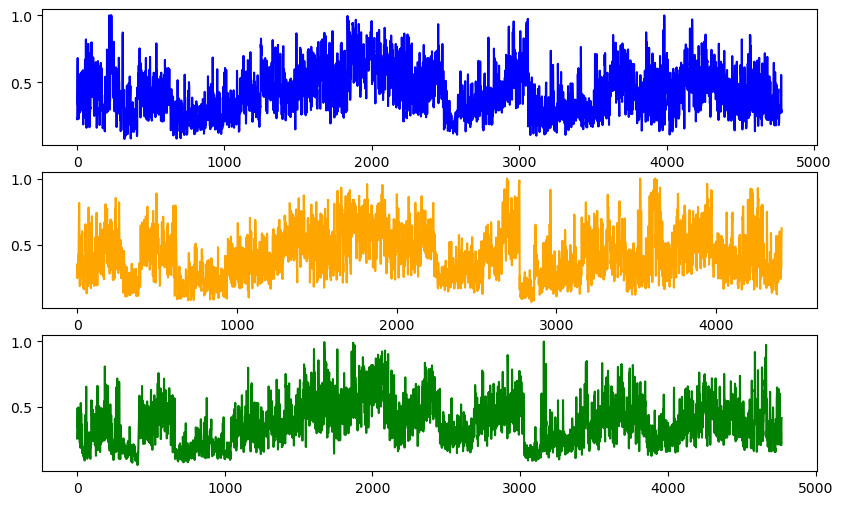

In [27]:
plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 1)
plt.plot(df_mu_10['recurrence_rate'], label='Carga 10', color='blue')

plt.subplot(3, 1, 2)

plt.plot(df_mu_5['recurrence_rate'], label='Carga 5', color='orange')

plt.subplot(3, 1, 3)

plt.plot(df_mu_0['recurrence_rate'], label='Carga 0', color='green')


In [28]:
df_mu_0.head()

,recurrence_rate,determinism,trapping_time,diag_entropy,vert_entropy,laminarity,Binaria,banda,archivo,condicion,sujeto,sesion
0,0.260000,0.849315,4.153488,1.450211,1.932627,0.954060,0.0,beta,pasivoPre.csv,0% Torque,AlejandoPayan,S1
1,0.358889,0.949675,6.520619,1.986399,2.377601,0.979102,0.0,beta,pasivoPre.csv,0% Torque,AlejandoPayan,S1
2,0.449444,0.957638,6.870690,1.997591,2.538217,0.985167,0.0,beta,pasivoPre.csv,0% Torque,AlejandoPayan,S1
3,0.486667,0.957447,6.200717,1.867356,2.452292,0.987443,1.0,beta,pasivoPre.csv,0% Torque,AlejandoPayan,S1
4,0.492778,0.906651,5.286154,1.823057,2.212693,0.968433,1.0,beta,pasivoPre.csv,0% Torque,AlejandoPayan,S1


In [29]:
from scipy.stats import kruskal
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel

In [30]:

def compute_kruskal_wallis_anova(df, group_column, value_column):
    """
    Computes the Kruskal-Wallis H-test for given groups in a DataFrame.

    Parameters:
    - df: DataFrame containing the data.
    - group_column: Column name in df that contains the group labels.
    - value_column: Column name in df that contains the values to compare across groups.

    Returns:
    - The test statistic and p-value from the Kruskal-Wallis H-test.
    """
    
    groups = df[group_column].unique()
    
    group_data = [df[df[group_column] == group][value_column] for group in groups]
    
    test_stat, p_value = kruskal(*group_data)
    
    return test_stat, p_value


def compute_one_way_anova(df, group_column, value_column):
    """
    Computes the one-way ANOVA test for given groups in a DataFrame.

    Parameters:
    - df: DataFrame containing the data.
    - group_column: Column name in df that contains the group labels.
    - value_column: Column name in df that contains the values to compare across groups.

    Returns:
    - The F statistic and p-value from the one-way ANOVA test.
    """
    
    groups = df[group_column].unique()
    
    group_data = [df[df[group_column] == group][value_column] for group in groups]
    
    F_stat, p_value = f_oneway(*group_data)
    
    return F_stat, p_value


def compute_two_way_anova(df, dependent_var, factor1, factor2):
    """
    Computes the two-way ANOVA for a given DataFrame.

    Parameters:
    - df: DataFrame containing the data.
    - dependent_var: The name of the dependent variable (continuous).
    - factor1: The name of the first factor (independent variable).
    - factor2: The name of the second factor (independent variable).

    Returns:
    - ANOVA table as a DataFrame.
    """
    # Construct the formula for the two-way ANOVA
    formula = f'{dependent_var} ~ C({factor1}) + C({factor2}) + C({factor1}):C({factor2})'
    
    # Fit the model
    model = ols(formula, data=df).fit()
    
    # Perform ANOVA and return the table
    anova_table = sm.stats.anova_lm(model, typ=2)
    return anova_table
def compute_t_test(df, group_column, value_column):
    """
    Computes the t-test for the means of two independent groups in a DataFrame.

    Parameters:
    - df: DataFrame containing the data.
    - group_column: Column name in df that contains the group labels.
    - value_column: Column name in df that contains the values to compare.
    - group1_label: The label of the first group for comparison.
    - group2_label: The label of the second group for comparison.

    Returns:
    - The T statistic and p-value from the t-test.
    """
    groups = df[group_column].unique()
    if(groups.shape[0] != 2):
        raise ValueError("Los gurpos deben de ser unicamente dos")
    # Extract data for the two specified groups
    group1_data = df[df[group_column] == groups[0]][value_column]
    group2_data = df[df[group_column] == groups[1]][value_column]
    
    # Perform the t-test
    T_stat, p_value = ttest_ind(group1_data, group2_data)
    
    return T_stat, p_value



def compute_paired_t_test(df, group_column, value_column):
    """
    Computes the paired t-test for the means of two related groups in a DataFrame.

    Parameters:
    - df: DataFrame containing the data.
    - group_column: Column name in df that contains the group labels.
    - value_column: Column name in df that contains the values to compare.

    Returns:
    - The T statistic and p-value from the paired t-test.
    """
    groups = df[group_column].unique()
    if len(groups) != 3:
        raise ValueError("Los gurpos deben de ser unicamente dos")
    
    # Extract data for the two specified groups
    group1_data = df[df[group_column] == groups[0]][value_column]
    group2_data = df[df[group_column] == groups[1]][value_column]
    
    # Ensure both groups have the same number of observations
    if len(group1_data) != len(group2_data):
        raise ValueError("Both groups must have the same number of observations for a paired t-test.")
    
    # Perform the paired t-test
    T_stat, p_value = ttest_rel(group1_data, group2_data)
    
    return T_stat, p_value

In [31]:
import numpy as np
import pandas as pd

def interpolate_df(df, target_len):
    """
    Interpola un DataFrame a un número fijo de filas (target_len).
    Asume que las columnas son numéricas excepto 'condicion'.
    """
    df_interp = pd.DataFrame()
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        x_old = np.linspace(0, 1, len(df))
        x_new = np.linspace(0, 1, target_len)
        df_interp[col] = np.interp(x_new, x_old, df[col].values)

    # Copiamos la columna 'condicion' como constante
    df_interp["condicion"] = df["condicion"].iloc[0]

    return df_interp


In [32]:
df_mu_10_norep = df_mu_10[df_mu_10["Binaria"] > 0.5].reset_index(drop=True)
df_mu_10_norep = df_mu_10_norep.drop(columns=['banda', 'archivo', 'sujeto', 'sesion'])

df_mu_5_norep = df_mu_5[df_mu_5["Binaria"] > 0.5].reset_index(drop=True)
df_mu_5_norep = df_mu_5_norep.drop(columns=['banda', 'archivo', 'sujeto', 'sesion'])

df_mu_0_norep = df_mu_0[df_mu_0["Binaria"] > 0.5].reset_index(drop=True)
df_mu_0_norep = df_mu_0_norep.drop(columns=['banda', 'archivo', 'sujeto', 'sesion'])


# Elegimos el número de muestras que queremos (por ejemplo, el mínimo entre los 3)
min_len = min(len(df_mu_10_norep), len(df_mu_5_norep), len(df_mu_0_norep))

# Interpolamos todos
#df_mu_10_interp = interpolate_df(df_mu_10_norep, min_len)
#df_mu_5_interp = interpolate_df(df_mu_5_norep, min_len)
#df_mu_0_interp = interpolate_df(df_mu_0_norep, min_len)

# Concatenamos todo
big_df_interp = pd.concat([df_mu_10_norep, df_mu_5_norep, df_mu_0_norep], ignore_index=True)

#big_df_interp["condicion"] = big_df_interp["condicion"].replace({
#    "10% Torque": 10,
#    "5% Torque": 5,
#    "0% Torque": 0
#})


big_df_interp

,recurrence_rate,determinism,trapping_time,diag_entropy,vert_entropy,laminarity,Binaria,condicion
0,0.581111,0.967520,8.365854,2.333927,2.684821,0.983748,1.0,10% Torque
1,0.682222,0.983306,8.614841,2.417993,2.794066,0.992671,1.0,10% Torque
2,0.368333,0.947867,5.769912,1.961845,2.329327,0.983409,1.0,10% Torque
3,0.327778,0.944643,6.605714,1.909903,2.218117,0.979661,1.0,10% Torque
4,0.567222,0.970737,8.100402,2.237687,2.576206,0.987757,1.0,10% Torque
...,...,...,...,...,...,...,...,...
9271,0.261111,0.927273,4.564356,1.853869,2.021555,0.980851,1.0,0% Torque
9272,0.312778,0.945591,5.390244,1.792075,2.198978,0.981350,1.0,0% Torque
9273,0.336667,0.937500,5.502326,1.961739,2.266798,0.976073,1.0,0% Torque
9274,0.297222,0.881188,4.811321,1.843727,2.132551,0.953271,1.0,0% Torque


In [33]:
df_mu_10.head()

,recurrence_rate,determinism,trapping_time,diag_entropy,vert_entropy,laminarity,Binaria,banda,archivo,condicion,sujeto,sesion
0,0.231667,0.904393,4.845238,1.701772,2.101651,0.976019,0.0,beta,10deTorquePre.csv,10% Torque,AlejandoPayan,S1
1,0.224444,0.919786,5.458333,1.769392,2.188482,0.972772,0.0,beta,10deTorquePre.csv,10% Torque,AlejandoPayan,S1
2,0.437778,0.957784,6.154150,2.095343,2.361912,0.987944,0.0,beta,10deTorquePre.csv,10% Torque,AlejandoPayan,S1
3,0.581111,0.967520,8.365854,2.333927,2.684821,0.983748,1.0,beta,10deTorquePre.csv,10% Torque,AlejandoPayan,S1
4,0.682222,0.983306,8.614841,2.417993,2.794066,0.992671,1.0,beta,10deTorquePre.csv,10% Torque,AlejandoPayan,S1


In [34]:
def get_significat_cols(df_analisis, p_val=0.05, label="label", test="one_way_anova", verbose=False):
    significat_cols = []
    p_values = []

    for col in df_analisis.columns:
        if col == label:
            continue

        try:
            if test == "paired_t_test":
                _, p_value = compute_paired_t_test(df_analisis, label, col)
            elif test == "t_test":
                _, p_value = compute_t_test(df_analisis, label, col)
            elif test == "kruskal_wallis":
                _, p_value = compute_kruskal_wallis_anova(df_analisis, label, col)
            elif test == "one_way_anova":
                _, p_value = compute_one_way_anova(df_analisis, label, col)
            else:
                raise ValueError(f"Unknown test: {test}")

            if p_value < p_val:
                significat_cols.append(col)
                p_values.append(p_value)
                if verbose:
                    plt.figure(figsize=(5, 6))
                    sns.violinplot(x=label, y=col, data=df_analisis, hue=label, fill=True, log_scale=False, alpha=1, palette="Blues")
                    #plt.title(f"{col} - p={p_value:.4f}")
                    plt.title(f"{band}  - {col}")
                    
                    plt.show()
        except Exception as e:
            print(f"Error testing {col}: {e}")

    return significat_cols, p_values


In [35]:
%matplotlib inline

In [36]:
big_df_interp

,recurrence_rate,determinism,trapping_time,diag_entropy,vert_entropy,laminarity,Binaria,condicion
0,0.581111,0.967520,8.365854,2.333927,2.684821,0.983748,1.0,10% Torque
1,0.682222,0.983306,8.614841,2.417993,2.794066,0.992671,1.0,10% Torque
2,0.368333,0.947867,5.769912,1.961845,2.329327,0.983409,1.0,10% Torque
3,0.327778,0.944643,6.605714,1.909903,2.218117,0.979661,1.0,10% Torque
4,0.567222,0.970737,8.100402,2.237687,2.576206,0.987757,1.0,10% Torque
...,...,...,...,...,...,...,...,...
9271,0.261111,0.927273,4.564356,1.853869,2.021555,0.980851,1.0,0% Torque
9272,0.312778,0.945591,5.390244,1.792075,2.198978,0.981350,1.0,0% Torque
9273,0.336667,0.937500,5.502326,1.961739,2.266798,0.976073,1.0,0% Torque
9274,0.297222,0.881188,4.811321,1.843727,2.132551,0.953271,1.0,0% Torque


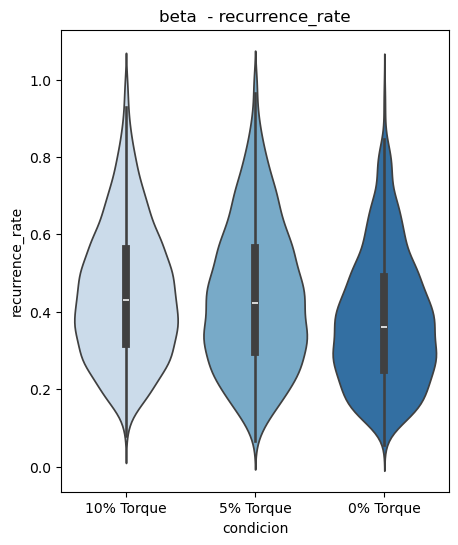

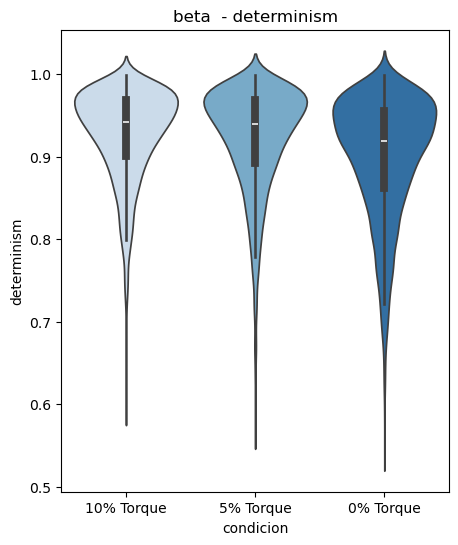

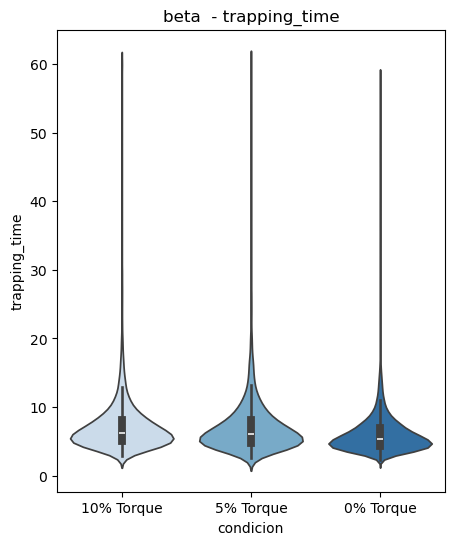

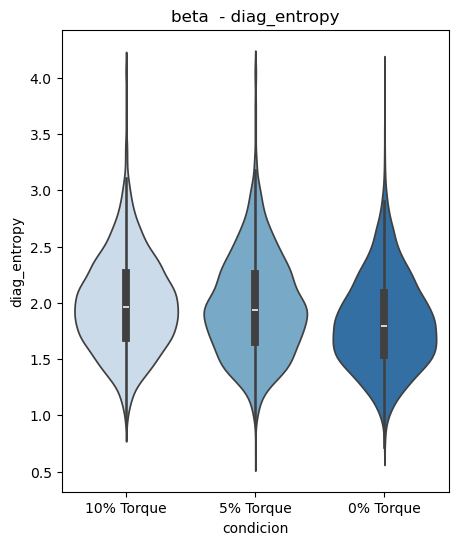

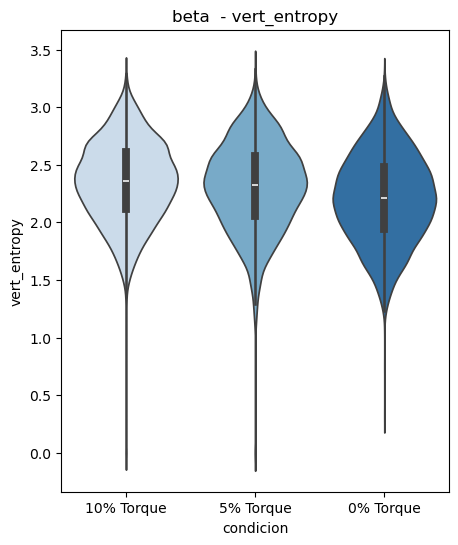

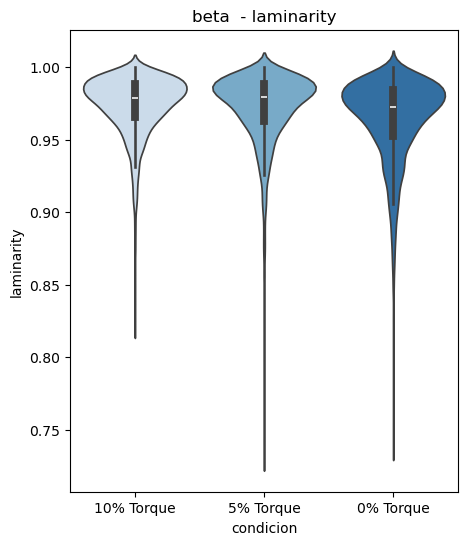

(['recurrence_rate',
  'determinism',
  'trapping_time',
  'diag_entropy',
  'vert_entropy',
  'laminarity'],
 [np.float64(4.0475919360671336e-61),
  np.float64(7.303409829174408e-67),
  np.float64(8.123088384085273e-39),
  np.float64(2.983822017811567e-60),
  np.float64(5.210595142410205e-50),
  np.float64(1.7188876730157448e-56)])

In [37]:
get_significat_cols(big_df_interp, p_val=0.01, test="one_way_anova", verbose=True, label="condicion")

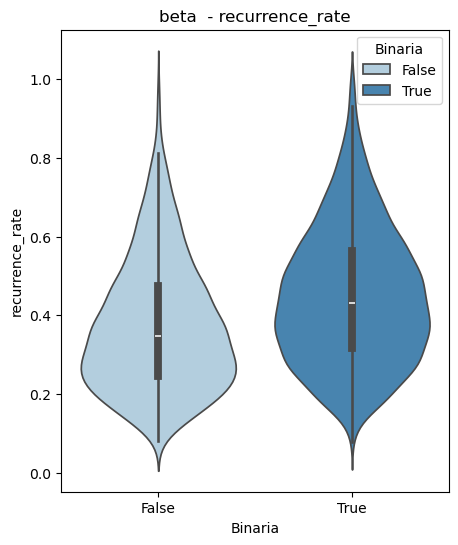

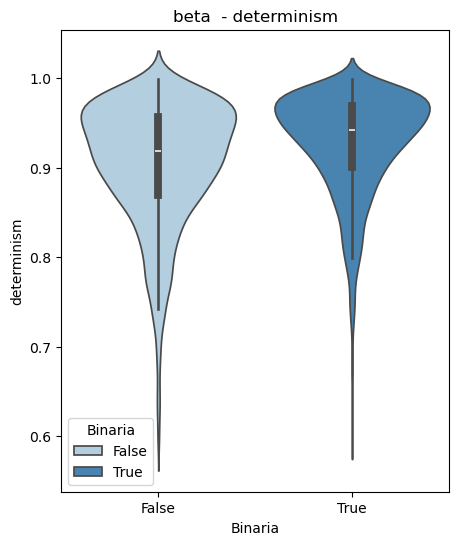

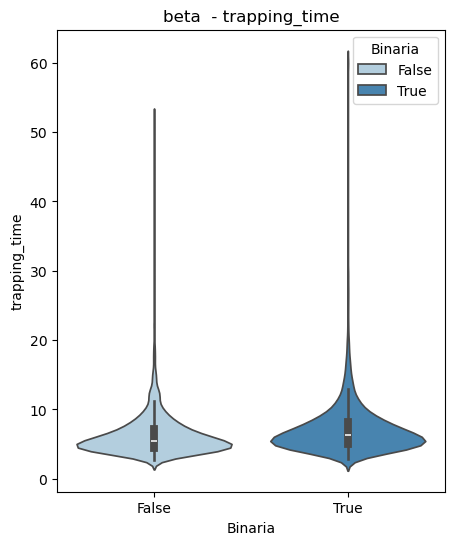

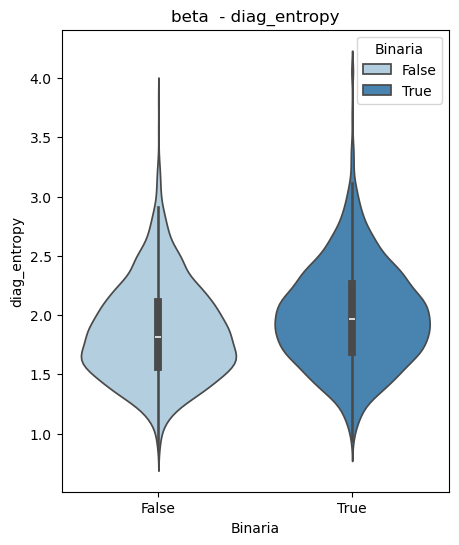

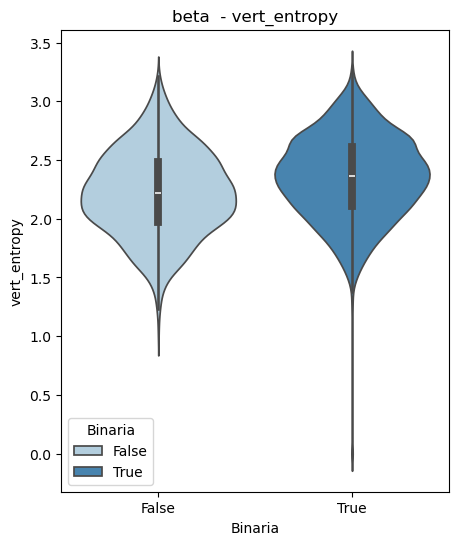

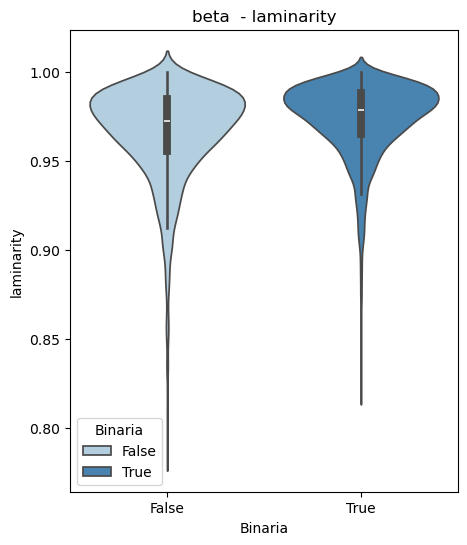

(['recurrence_rate',
  'determinism',
  'trapping_time',
  'diag_entropy',
  'vert_entropy',
  'laminarity'],
 [np.float64(5.777932598582437e-46),
  np.float64(2.7421680743872472e-33),
  np.float64(4.981655494794026e-16),
  np.float64(3.021659714041911e-26),
  np.float64(7.056701135235891e-31),
  np.float64(7.066550648194877e-27)])

In [38]:
df_mu_10["Binaria"] = df_mu_10["Binaria"] > 0.5
get_significat_cols(df_mu_10.drop(columns=['banda', 'archivo', 'sujeto', 'sesion', 'condicion']), p_val=2, test="t_test", verbose=True, label="Binaria")